Train Size: 10119
Test Size : 2530

🚀 [Step 2] 啟動 5-Fold CV (Full Data + Oversampling)...
   Running Fold 5/5...
   ✅ 5-Fold CV 平均 F1: 0.6329

🚀 [Step 3] 最終全量訓練...
   Epoch 1 done.
   Epoch 2 done.
   Epoch 3 done.
   Epoch 4 done.

📝 [Step 4] 最終測試...

🏆 【 實驗結果：Focal Loss + Full Data 】
Accuracy : 0.6308
F1-Score : 0.6457
Recall   : 0.8587
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.8418    0.4841    0.6147      1539
           1     0.5173    0.8587    0.6457       991

    accuracy                         0.6308      2530
   macro avg     0.6796    0.6714    0.6302      2530
weighted avg     0.7147    0.6308    0.6268      2530

------------------------------------------------------------


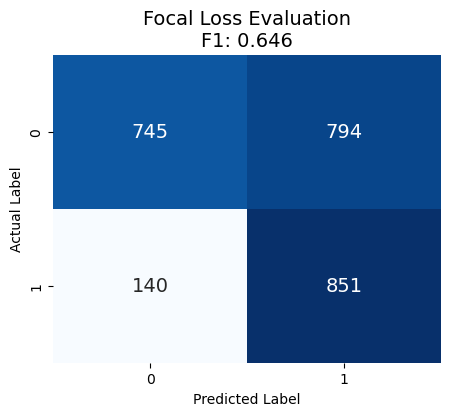

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW 
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# ⚙️ 設定區
# ==========================================
INPUT_CSV = 'News_Data_cleaned_2.csv'
MODEL_NAME = 'hfl/chinese-macbert-base'
MAX_LEN = 256
BATCH_SIZE = 32
EPOCHS = 4
LEARNING_RATE = 2e-5
SEED = 42
CV_FOLDS = 5

if torch.backends.mps.is_available(): DEVICE = torch.device("mps")
elif torch.cuda.is_available(): DEVICE = torch.device("cuda")
else: DEVICE = torch.device("cpu")

def set_seed(seed_value=42):
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed_value)
set_seed(SEED)

# ==========================================
# 1. 資料準備
# ==========================================
if not os.path.exists(INPUT_CSV): 
    print(f"❌ 找不到 {INPUT_CSV}")
    exit()

df = pd.read_csv(INPUT_CSV)
df = df.dropna(subset=['title_clean', 'label'])
df['label'] = df['label'].astype(int)

# 特徵提取
def get_feature_matrix(df_in):
    f1 = df_in[['title_len', 'punct_count', 'has_digit']].values
    f2 = df_in[['hour', 'is_prime_time', 'is_work_hour', 'is_weekend']].values
    f3 = df_in[['viral_latency_hours', 'is_instant_viral']].fillna(0).values
    feats = np.hstack([f1, f2, f3])
    scaler = MinMaxScaler()
    return scaler.fit_transform(feats)

# ==========================================
# ✂️ Step 1: 嚴格切分 80/20
# ==========================================
X_stats_all = get_feature_matrix(df)
X_txt_all = df['title_clean'].values
y_all = df['label'].values
indices = np.arange(len(df))

X_txt_tr, X_txt_te, X_stats_tr, X_stats_te, y_tr, y_te = train_test_split(
    X_txt_all, X_stats_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

print(f"Train Size: {len(y_tr)}")
print(f"Test Size : {len(y_te)}")

# ==========================================
# 🔥 關鍵：定義 Focal Loss
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        CE_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-CE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * CE_loss

        if self.reduction == 'mean': return torch.mean(F_loss)
        elif self.reduction == 'sum': return torch.sum(F_loss)
        else: return F_loss

# Dataset & Model
class HybridDataset(Dataset):
    def __init__(self, texts, extra, labels, tokenizer, max_len):
        self.texts = texts; self.extra = extra; self.labels = labels
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, item):
        enc = self.tokenizer.encode_plus(str(self.texts[item]), add_special_tokens=True, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'extra': torch.tensor(self.extra[item], dtype=torch.float32),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

class HybridMacBERT(nn.Module):
    def __init__(self, model_name, num_labels=2):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        # 768 + 9 = 777
        self.cls = nn.Sequential(nn.Linear(768+9, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, num_labels))
    def forward(self, ids, mask, extra):
        out = self.bert(ids, mask).pooler_output
        return self.cls(torch.cat((out, extra), dim=1))

def get_probs(model, loader, device):
    model.eval()
    probs = []
    with torch.no_grad():
        for d in loader:
            out = model(d['input_ids'].to(device), d['attention_mask'].to(device), d['extra'].to(device))
            probs.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
    return np.array(probs)

def train_epoch_focal(model, loader, opt, device, sched):
    model.train()
    crit = FocalLoss(alpha=0.25, gamma=2.0)
    for d in loader:
        opt.zero_grad()
        out = model(d['input_ids'].to(device), d['attention_mask'].to(device), d['extra'].to(device))
        loss = crit(out, d['labels'].to(device))
        loss.backward()
        opt.step(); sched.step()

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# ==========================================
# 🚀 Step 2: 5-Fold CV
# ==========================================
print("\n🚀 [Step 2] 啟動 5-Fold CV (Full Data + Oversampling)...")

def create_weighted_loader(dataset, labels, batch_size):
    class_counts = np.bincount(labels)
    class_weights = 1. / class_counts
    sample_weights = [class_weights[t] for t in labels]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
    return DataLoader(dataset, batch_size=batch_size, sampler=sampler)

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_txt_tr, y_tr)):
    print(f"   Running Fold {fold+1}/{CV_FOLDS}...", end="\r")
    
    ds_tr = HybridDataset(X_txt_tr[tr_idx], X_stats_tr[tr_idx], y_tr[tr_idx], tokenizer, MAX_LEN)
    ds_val = HybridDataset(X_txt_tr[val_idx], X_stats_tr[val_idx], y_tr[val_idx], tokenizer, MAX_LEN)
    
    ld_tr = create_weighted_loader(ds_tr, y_tr[tr_idx], BATCH_SIZE)
    ld_val = DataLoader(ds_val, BATCH_SIZE)
    
    model = HybridMacBERT(MODEL_NAME).to(DEVICE)
    opt = AdamW(model.parameters(), lr=LEARNING_RATE)
    sch = get_linear_schedule_with_warmup(opt, 0, len(ld_tr)*EPOCHS)
    
    for ep in range(EPOCHS):
        train_epoch_focal(model, ld_tr, opt, DEVICE, sch)
        
    probs_val = get_probs(model, ld_val, DEVICE)
    best_f1 = max([f1_score(y_tr[val_idx], (probs_val>=th).astype(int)) for th in np.arange(0.1, 0.8, 0.05)])
    fold_scores.append(best_f1)
    
    del model
    if torch.backends.mps.is_available(): torch.mps.empty_cache()
    elif torch.cuda.is_available(): torch.cuda.empty_cache()

print(f"\n   ✅ 5-Fold CV 平均 F1: {np.mean(fold_scores):.4f}")

# ==========================================
# 🚀 Step 3: 最終全量訓練
# ==========================================
print("\n🚀 [Step 3] 最終全量訓練...")
ds_full = HybridDataset(X_txt_tr, X_stats_tr, y_tr, tokenizer, MAX_LEN)
ld_full = create_weighted_loader(ds_full, y_tr, BATCH_SIZE)

model_final = HybridMacBERT(MODEL_NAME).to(DEVICE)
opt = AdamW(model_final.parameters(), lr=LEARNING_RATE)
sch = get_linear_schedule_with_warmup(opt, 0, len(ld_full)*EPOCHS)

for ep in range(EPOCHS):
    train_epoch_focal(model_final, ld_full, opt, DEVICE, sch)
    print(f"   Epoch {ep+1} done.")

# ==========================================
# 📝 Step 4: 最終測試 (Lock Test Set)
# ==========================================
print("\n📝 [Step 4] 最終測試...")
ds_test = HybridDataset(X_txt_te, X_stats_te, y_te, tokenizer, MAX_LEN)
ld_test = DataLoader(ds_test, BATCH_SIZE)
probs_test = get_probs(model_final, ld_test, DEVICE)

# 搜尋最佳閾值
best_f1, best_th = 0, 0.1
for th in np.arange(0.1, 0.8, 0.01):
    f1 = f1_score(y_te, (probs_test>=th).astype(int))
    if f1 > best_f1: best_f1, best_th = f1, th
y_pred = (probs_test >= best_th).astype(int)

# 生成報告數據
acc = accuracy_score(y_te, y_pred)
prec = precision_score(y_te, y_pred)
rec = recall_score(y_te, y_pred)

# ==========================================
# 🏆 格式化輸出 (依照您的 PDF 格式)
# ==========================================
print("\n" + "="*80)
print(f"🏆 【 實驗結果：Focal Loss + Full Data 】")
print("="*80)
print(f"Accuracy : {acc:.4f}")
print(f"F1-Score : {best_f1:.4f}")
print(f"Recall   : {rec:.4f}")
print("-" * 60)
print(classification_report(y_te, y_pred, digits=4))
print("-" * 60)

# 畫混淆矩陣
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title(f'Focal Loss Evaluation\nF1: {best_f1:.3f}', fontsize=14)
plt.ylabel('Actual Label'); plt.xlabel('Predicted Label')
plt.show()